# Born in Simulation — V3: Visual Domain Randomization for Sim-to-Real Transfer

**Seminar in AI (340.910) — JKU Linz | Saqib Ali Khan (K12343661)**

This is the final and most rigorous version (V3) of the experiment. It investigates
how the diversity of visual domain randomization affects sim-to-real transfer accuracy
for object recognition, grounded in Tobin et al. (2017).

## What V3 improves over earlier versions

| | V1 | V2 | **V3 (this notebook)** |
|---|---|---|---|
| Images per class | 500 | 1,000 | **5,000** |
| Seed formula | buggy — levels ≥500 collided | fixed | **fixed** |
| Epochs | fixed 10 | fixed 10 | **early stopping, max 100** |
| Validation split | none | none | **15% stratified per class** |
| Ablation | none | none | **from-scratch (no pretraining)** |

**V1 revealed a seed-collision bug** where texture levels 500, 1000, and 5000 generated
identical training data (because `i % texture_level == i` when the image index never
reaches the level). **V2 fixed the seed formula.** **V3** scales the data to 5,000
images per class so even Level 5000 reaches genuinely unique renders, adds early stopping
with a stratified validation split, and adds a from-scratch ablation to isolate the
contribution of ImageNet pretraining.

## Experiment design

- **Task:** 5-class object recognition (mug, mustard bottle, power drill, bowl, bleach cleanser)
- **Train:** synthetic PyBullet renders with domain randomization (colour, camera, distractors)
- **Test:** real YCB RGB photographs — never seen during training
- **Metric:** top-1 accuracy on real images (random chance = 20%)
- **Model:** ResNet-18 pretrained on ImageNet, fully fine-tuned (no frozen layers)

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import os, csv, random, time
from pathlib import Path

import numpy as np
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset

from torchvision import models, transforms

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import pybullet as p
import pybullet_data

from tqdm.auto import tqdm

# ── GPU check ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM   : 6.4 GB
PyTorch: 2.2.1+cu121


## Configuration

All paths and hyperparameters in one place. Only `BASE_DIR` needs changing to run
on a different machine. The V3 outputs are kept in separate `_v3` folders so they
never collide with V1 or V2 results.

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment")
MESH_DIR    = BASE_DIR / "3D mesh for simulation (16k )"
RGB_DIR     = BASE_DIR / "RGB images for testing"

# V3-specific output folders
SYNTH_DIR_V3   = BASE_DIR / "synthetic_images_v3"
MODELS_DIR_V3  = BASE_DIR / "trained_models_v3"
RESULTS_DIR_V3 = BASE_DIR / "results_v3"

for folder in [SYNTH_DIR_V3, MODELS_DIR_V3, RESULTS_DIR_V3]:
    folder.mkdir(exist_ok=True)

# ── YCB objects (5 classes) ────────────────────────────────────────────────
OBJECTS = [
    "025_mug",
    "006_mustard_bottle",
    "035_power_drill",
    "024_bowl",
    "021_bleach_cleanser",
]
CLASS_MAP = {i: obj for i, obj in enumerate(OBJECTS)}

# ── Texture diversity levels ───────────────────────────────────────────────
TEXTURE_LEVELS = [10, 100, 500, 1000, 5000]
ALL_LEVELS     = [0] + TEXTURE_LEVELS   # [0, 10, 100, 500, 1000, 5000]

# ── V3 dataset / training settings ─────────────────────────────────────────
IMAGES_V3    = 5000          # images per class — genuine max diversity at Level 5000
IMG_SIZE     = 224
BATCH_SIZE   = 32
LR           = 1e-4

MAX_EPOCHS   = 100           # upper bound — early stopping ends sooner
ES_PATIENCE  = 12            # stop if val loss doesn't improve for this many epochs
VAL_FRACTION = 0.15          # held-out fraction per class (stratified)

# ── Verify inputs exist ────────────────────────────────────────────────────
print("Input folders:")
print(f"  Mesh dir : {'OK' if MESH_DIR.exists() else 'MISSING'}  {MESH_DIR}")
print(f"  RGB dir  : {'OK' if RGB_DIR.exists()  else 'MISSING'}  {RGB_DIR}")

print("\nMesh files:")
for obj in OBJECTS:
    mesh = MESH_DIR / obj / "google_16k" / "textured.obj"
    print(f"  {obj}: {'OK' if mesh.exists() else 'MISSING'}")

print("\nV3 configuration:")
print(f"  Images per class : {IMAGES_V3}")
print(f"  Total images     : {len(ALL_LEVELS) * len(OBJECTS) * IMAGES_V3:,}")
print(f"  Max epochs       : {MAX_EPOCHS}  (early stopping patience {ES_PATIENCE})")
print(f"  Validation split : {VAL_FRACTION:.0%} per class (stratified)")

Input folders:
  Mesh dir : OK  C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\3D mesh for simulation (16k )
  RGB dir  : OK  C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\RGB images for testing

Mesh files:
  025_mug: OK
  006_mustard_bottle: OK
  035_power_drill: OK
  024_bowl: OK
  021_bleach_cleanser: OK

V3 configuration:
  Images per class : 5000
  Total images     : 150,000
  Max epochs       : 100  (early stopping patience 12)
  Validation split : 15% per class (stratified)


## The Domain Randomized Renderer

Renders YCB `.obj` meshes in PyBullet's headless mode with **visual domain
randomization** (Tobin et al. 2017). This is scene-level randomization, not image
augmentation — each render varies the 3D scene before rendering:

- **Object colour** — random RGBA tint
- **Floor colour** — random RGBA
- **Camera** — random distance (0.35–0.75 m), yaw (0–360°), pitch (−70° to −15°)
- **Distractors** — 0–4 random coloured boxes placed in the 3D scene

When `randomize=False` (the Model 0 baseline) every render is identical: fixed grey
floor, fixed red object, fixed camera. The model can only learn the object's colour,
not its shape — which is why it fails to transfer to real images.

The cell ends with a 4-image smoke test to confirm the renderer works.

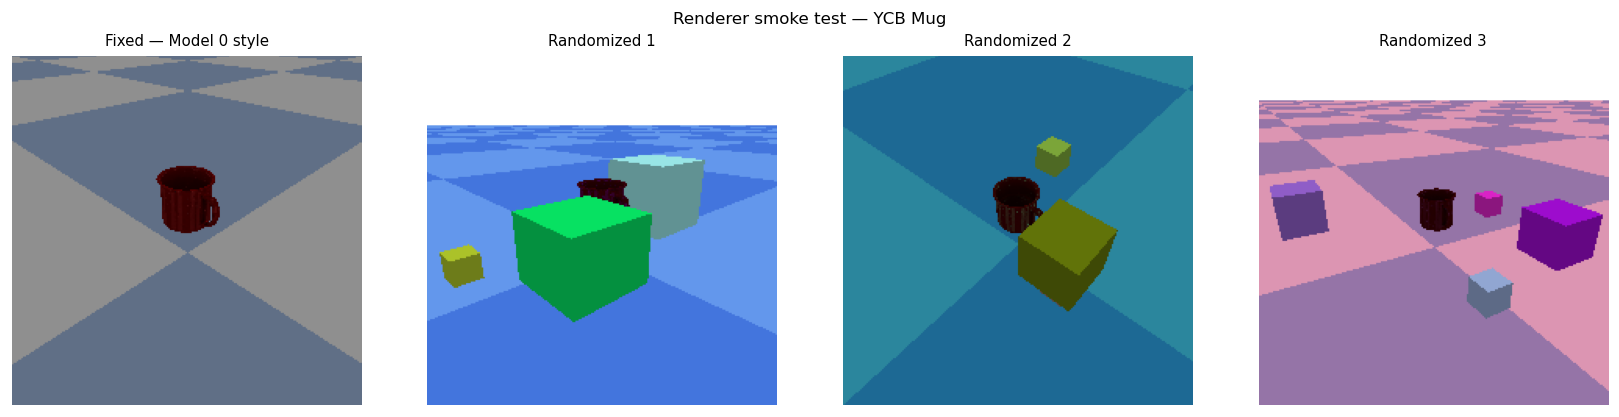

Renderer OK


In [3]:
class DomainRandomizedRenderer:
    """
    Renders YCB .obj meshes in PyBullet with visual domain randomization.
    Ref: Tobin et al. 2017.
    """

    def __init__(self, img_size=224):
        self.img_size = img_size
        self.physics_client = None

    def connect(self):
        if self.physics_client is not None:
            try: p.disconnect(self.physics_client)
            except Exception: pass
        self.physics_client = p.connect(p.DIRECT)   # headless
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -9.81)

    def disconnect(self):
        if self.physics_client is not None:
            try: p.disconnect(self.physics_client)
            except Exception: pass
            self.physics_client = None

    def _random_color(self):
        return [random.random(), random.random(), random.random(), 1.0]

    def render_object(self, mesh_path, randomize=True,
                      distance=0.5, yaw=45, pitch=-35):
        p.resetSimulation()
        p.setGravity(0, 0, -9.81)

        # Floor
        plane_id    = p.loadURDF("plane.urdf")
        floor_color = self._random_color() if randomize else [0.6, 0.6, 0.6, 1.0]
        p.changeVisualShape(plane_id, -1, rgbaColor=floor_color)

        # Main object
        try:
            vis_id = p.createVisualShape(
                p.GEOM_MESH, fileName=str(mesh_path), meshScale=[1, 1, 1],
                rgbaColor=self._random_color() if randomize else [0.8, 0.2, 0.2, 1.0]
            )
            col_id = p.createCollisionShape(
                p.GEOM_MESH, fileName=str(mesh_path), meshScale=[1, 1, 1]
            )
            obj_id = p.createMultiBody(
                baseMass=0.1, baseCollisionShapeIndex=col_id,
                baseVisualShapeIndex=vis_id, basePosition=[0, 0, 0.05]
            )
        except Exception as e:
            print(f"Mesh load error ({mesh_path.name}): {e}")
            return None

        if randomize:
            p.changeVisualShape(obj_id, -1, rgbaColor=self._random_color())

        # Distractor boxes (Tobin et al. style)
        if randomize:
            for _ in range(random.randint(0, 4)):
                pos  = [random.uniform(-0.3, 0.3),
                        random.uniform(-0.3, 0.3),
                        random.uniform(0.02, 0.15)]
                size = random.uniform(0.02, 0.08)
                vis  = p.createVisualShape(p.GEOM_BOX, halfExtents=[size]*3,
                                           rgbaColor=self._random_color())
                col  = p.createCollisionShape(p.GEOM_BOX, halfExtents=[size]*3)
                p.createMultiBody(0, col, vis, pos)

        # Camera
        if randomize:
            distance = random.uniform(0.35, 0.75)
            yaw      = random.uniform(0, 360)
            pitch    = random.uniform(-70, -15)

        view_mat = p.computeViewMatrixFromYawPitchRoll(
            cameraTargetPosition=[0, 0, 0.05],
            distance=distance, yaw=yaw, pitch=pitch, roll=0, upAxisIndex=2
        )
        proj_mat = p.computeProjectionMatrixFOV(
            fov=60, aspect=1.0, nearVal=0.01, farVal=10.0
        )
        _, _, rgb, _, _ = p.getCameraImage(
            width=self.img_size, height=self.img_size,
            viewMatrix=view_mat, projectionMatrix=proj_mat,
            renderer=p.ER_TINY_RENDERER
        )
        arr = np.array(rgb, dtype=np.uint8).reshape(self.img_size, self.img_size, 4)
        return Image.fromarray(arr[:, :, :3])


def get_mesh_path(obj_name):
    """Confirmed textured.obj path for a YCB object."""
    return MESH_DIR / obj_name / "google_16k" / "textured.obj"


def get_level_name(texture_level):
    """Integer level -> canonical folder/filename string."""
    return "no_randomization" if texture_level == 0 else f"textures_{texture_level:05d}"


# ── Smoke test ──────────────────────────────────────────────────────────────
renderer = DomainRandomizedRenderer(img_size=IMG_SIZE)
renderer.connect()
mug_mesh = get_mesh_path("025_mug")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (title, rand) in zip(axes, [
    ("Fixed — Model 0 style", False),
    ("Randomized 1", True), ("Randomized 2", True), ("Randomized 3", True),
]):
    ax.imshow(np.array(renderer.render_object(mug_mesh, randomize=rand)))
    ax.set_title(title, fontsize=9); ax.axis("off")

plt.suptitle("Renderer smoke test — YCB Mug", fontsize=10)
plt.tight_layout(); plt.show()
renderer.disconnect()
print("Renderer OK")

## Synthetic Dataset Generation

Generates **5,000 images per class × 5 classes × 6 levels = 150,000 images**.

**Multi-class, no negative images** — every image shows one YCB object, labelled by which object it is (0–4). The folder structure encodes the label: `synthetic_images_v3/{level_name}/{obj_name}/{i:05d}.png`.

**Fixed seed formula (the V2 correction):**

`cycle_seed = 42 + obj_idx × 1,000,000 + texture_level × 100 + (i % texture_level)`

The `texture_level × 100` term is the fix — it shifts each level into its own seed range so levels no longer collide. Combined with 5,000 images per class, even Level 5000 produces genuinely unique renders (whereas in V1/V2 the image index never reached 5000, so higher levels repeated earlier ones).

> **Runtime note:** A fresh run generates all 150,000 images and takes several hours on a laptop GPU (~5 hours on an RTX 3060). Generation is **idempotent** — images already on disk are skipped, so interrupting and resuming is safe, and re-running after a completed run finishes in seconds.

In [4]:
def generate_dataset_v3(renderer, obj_name, texture_level,
                        images_per_class=5000, seed=42):
    """Generate synthetic training images for one (object, level) pair."""
    mesh_path  = get_mesh_path(obj_name)
    level_name = get_level_name(texture_level)
    obj_idx    = OBJECTS.index(obj_name)

    obj_dir = SYNTH_DIR_V3 / level_name / obj_name
    obj_dir.mkdir(parents=True, exist_ok=True)

    existing = len(list(obj_dir.glob("*.png")))
    if existing >= images_per_class:
        print(f"  {obj_name:35s} / {level_name}: complete — skipping")
        return

    print(f"  {obj_name:35s} / {level_name} ...", end="", flush=True)

    for i in range(images_per_class):
        img_path = obj_dir / f"{i:05d}.png"
        if img_path.exists():
            continue

        if texture_level == 0:
            img = renderer.render_object(mesh_path, randomize=False)
        else:
            cycle_seed = (seed
                          + obj_idx * 1_000_000
                          + texture_level * 100
                          + (i % texture_level))
            random.seed(cycle_seed)
            np.random.seed(cycle_seed)
            img = renderer.render_object(mesh_path, randomize=True)

        if img is not None:
            img.save(str(img_path))

    count = len(list(obj_dir.glob("*.png")))
    print(f" {count} images OK")


# ── Generation loop — 6 levels × 5 objects ─────────────────────────────────
TOTAL_JOBS_V3 = len(ALL_LEVELS) * len(OBJECTS)
print("=" * 66)
print(f"  V3 GENERATION — {TOTAL_JOBS_V3 * IMAGES_V3:,} images target")
print("=" * 66)

renderer_v3 = DomainRandomizedRenderer(img_size=IMG_SIZE)
renderer_v3.connect()

t0, completed, skipped, errors = time.time(), 0, 0, []
level_bar = tqdm(ALL_LEVELS, desc="Levels", unit="level", position=0)

for level in level_bar:
    label = get_level_name(level)
    level_bar.set_description(f"Level {label}")
    obj_bar = tqdm(OBJECTS, desc="  Objects", unit="obj", position=1, leave=False)

    for obj in obj_bar:
        obj_bar.set_description(f"  {obj}")
        obj_dir = SYNTH_DIR_V3 / label / obj
        n_exist = len(list(obj_dir.glob("*.png"))) if obj_dir.exists() else 0
        if n_exist >= IMAGES_V3:
            skipped += 1
            continue
        try:
            generate_dataset_v3(renderer_v3, obj, level, IMAGES_V3, seed=42)
            completed += 1
        except Exception as exc:
            errors.append(f"{label}/{obj}: {exc}")
            tqdm.write(f"  ERROR: {errors[-1]}")
    obj_bar.close()

renderer_v3.disconnect()
print(f"\nDone in {(time.time()-t0)/60:.1f} min  |  "
      f"Generated: {completed}  Skipped: {skipped}  Errors: {len(errors)}")

# Summary
for level in ALL_LEVELS:
    lname    = get_level_name(level)
    expected = len(OBJECTS) * IMAGES_V3
    total    = sum(len(list((SYNTH_DIR_V3 / lname / o).glob("*.png")))
                   for o in OBJECTS if (SYNTH_DIR_V3 / lname / o).exists())
    print(f"  {lname:<26} {total:>8,}  {'OK' if total==expected else 'INCOMPLETE'}")

  V3 GENERATION — 150,000 images target


Levels:   0%|          | 0/6 [00:00<?, ?level/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]


Done in 0.0 min  |  Generated: 0  Skipped: 30  Errors: 0
  no_randomization             25,000  OK
  textures_00010               25,000  OK
  textures_00100               25,000  OK
  textures_00500               25,000  OK
  textures_01000               25,000  OK
  textures_05000               25,000  OK


## Datasets and Transforms

Two dataset classes, both using the same label scheme (`OBJECTS.index(obj_name)` → 0–4):

- **`SyntheticDataset_V3(texture_level)`** — loads simulated training images from `synthetic_images_v3/`
- **`RealYCBDataset()`** — loads the real YCB test photographs from `RGB images for testing/`; these are never seen during training

**Transforms:** training uses resize → random horizontal flip → ImageNet normalisation. No colour jitter is applied — the simulation's domain randomization already provides colour diversity, so adding jitter would double-count it. The test transform is deterministic (resize → normalise only).

In [5]:
# ── Transforms ─────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),   # ImageNet stats
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


class SyntheticDataset_V3(Dataset):
    """Simulated training images for one texture level. Label = 0..4."""
    def __init__(self, texture_level, transform=None):
        self.transform = transform
        self.samples   = []
        level_name     = get_level_name(texture_level)
        for class_idx, obj_name in enumerate(OBJECTS):
            obj_dir = SYNTH_DIR_V3 / level_name / obj_name
            if not obj_dir.exists():
                print(f"  WARNING — missing: {obj_dir}")
                continue
            for img_path in sorted(obj_dir.glob("*.png")):
                self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class RealYCBDataset(Dataset):
    """Real YCB RGB test images. Label = 0..4. Never used during training."""
    def __init__(self, transform=None):
        self.transform = transform
        self.samples   = []
        for class_idx, obj_name in enumerate(OBJECTS):
            obj_dir = RGB_DIR / obj_name
            if not obj_dir.exists():
                print(f"  WARNING — missing: {obj_dir}")
                continue
            imgs = (list(obj_dir.rglob("*.jpg"))  +
                    list(obj_dir.rglob("*.JPG"))  +
                    list(obj_dir.rglob("*.jpeg")) +
                    list(obj_dir.rglob("*.png")))
            for pth in sorted(set(imgs)):
                self.samples.append((pth, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Sanity check ────────────────────────────────────────────────────────────
print(f"Class map: {CLASS_MAP}\n")

print("Synthetic training sets (V3):")
for level in ALL_LEVELS:
    ds       = SyntheticDataset_V3(level)
    expected = len(OBJECTS) * IMAGES_V3
    flag     = "OK" if len(ds) == expected else f"WARNING — expected {expected}"
    print(f"  {get_level_name(level):<26}: {len(ds):>6} images  {flag}")

real_ds = RealYCBDataset()
print(f"\nReal YCB test set: {len(real_ds)} images")
for i, obj in enumerate(OBJECTS):
    count = sum(1 for _, l in real_ds.samples if l == i)
    print(f"  Class {i} — {obj}: {count} images")

Class map: {0: '025_mug', 1: '006_mustard_bottle', 2: '035_power_drill', 3: '024_bowl', 4: '021_bleach_cleanser'}

Synthetic training sets (V3):
  no_randomization          :  25000 images  OK
  textures_00010            :  25000 images  OK
  textures_00100            :  25000 images  OK
  textures_00500            :  25000 images  OK
  textures_01000            :  25000 images  OK
  textures_05000            :  25000 images  OK

Real YCB test set: 3000 images
  Class 0 — 025_mug: 600 images
  Class 1 — 006_mustard_bottle: 600 images
  Class 2 — 035_power_drill: 600 images
  Class 3 — 024_bowl: 600 images
  Class 4 — 021_bleach_cleanser: 600 images


## Model and Training

**Architecture:** ResNet-18 pretrained on ImageNet, with the final fully connected layer replaced (`Linear(512 → 5)`). All layers are trainable — no layers are frozen. Only the final classification head is replaced, which is the standard transfer-learning procedure, not layer freezing.

**Loss:** CrossEntropyLoss. **Optimiser:** Adam (lr=1e-4). **Scheduler:** ReduceLROnPlateau on validation loss.

**Early stopping with a stratified validation split:** 15% of each class is held out (stratified, so every class contributes exactly 15%) to give an honest signal for when the model stops improving. Training continues up to 100 epochs but stops when validation loss shows no improvement for 12 consecutive epochs. The best-by-validation-loss weights are restored before saving.

This addresses the "10 epochs is too few" critique — each model now trains until it genuinely converges. Low-diversity models stop early (~13 epochs); high-diversity models train longer (Level 1000 reached 24 epochs), because more diverse data takes longer to fit.

**Checkpointing:** each model saves to `trained_models_v3/model_{level_name}.pth` with its full training history. Re-running skips levels whose checkpoints already exist.

In [6]:
def build_model(num_classes=5):
    """ResNet-18 pretrained on ImageNet, final FC replaced (512 -> num_classes).
       All layers trainable — no freezing."""
    model    = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def train_one_level_v3(texture_level, verbose=True):
    """Train one ResNet-18 with stratified validation split + early stopping.
       Saves best-by-val-loss weights to MODELS_DIR_V3."""
    from collections import defaultdict

    level_name = get_level_name(texture_level)
    model_path = MODELS_DIR_V3 / f"model_{level_name}.pth"

    if model_path.exists():
        ckpt = torch.load(model_path, map_location="cpu")
        if verbose:
            print(f"  [{level_name}] checkpoint found "
                  f"(stopped epoch {ckpt['history'].get('stopped_epoch','?')}) — skipping")
        return ckpt.get("history")

    if verbose:
        print(f"\n{'─'*58}")
        print(f"  V3 Training : {level_name}")
        print(f"{'─'*58}")

    full_ds = SyntheticDataset_V3(texture_level, transform=train_transform)

    # ── Stratified split — equal validation fraction per class ────────────
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(full_ds.samples):
        class_indices[label].append(idx)

    rng = random.Random(42)
    train_idx, val_idx = [], []
    for label, idxs in class_indices.items():
        idxs = idxs.copy()
        rng.shuffle(idxs)
        n_val_cls = int(len(idxs) * VAL_FRACTION)
        val_idx.extend(idxs[:n_val_cls])
        train_idx.extend(idxs[n_val_cls:])

    if verbose:
        print(f"  Stratified split: {len(train_idx)} train, {len(val_idx)} val")

    train_loader = DataLoader(Subset(full_ds, train_idx), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(Subset(full_ds, val_idx), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    model     = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
    best_val_loss, best_state, no_improve, stopped = float("inf"), None, 0, MAX_EPOCHS

    for epoch in range(1, MAX_EPOCHS + 1):
        # train
        model.train()
        rl, c, t = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            rl += loss.item() * imgs.size(0)
            _, pr = logits.max(1)
            t += labels.size(0); c += pr.eq(labels).sum().item()
        tr_loss, tr_acc = rl / t, 100.0 * c / t

        # validate
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs)
                loss   = criterion(logits, labels)
                vl += loss.item() * imgs.size(0)
                _, pr = logits.max(1)
                vt += labels.size(0); vc += pr.eq(labels).sum().item()
        val_loss, val_acc = vl / vt, 100.0 * vc / vt

        for k, v in [("loss", tr_loss), ("acc", tr_acc),
                     ("val_loss", val_loss), ("val_acc", val_acc)]:
            history[k].append(round(v, 5 if "loss" in k else 2))
        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1

        if verbose and (epoch <= 3 or epoch % 5 == 0 or no_improve >= ES_PATIENCE):
            print(f"  Epoch {epoch:03d}  tr_loss={tr_loss:.4f} tr_acc={tr_acc:5.1f}%  "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:5.1f}%  (no improve: {no_improve})")

        if no_improve >= ES_PATIENCE:
            stopped = epoch
            if verbose:
                print(f"  Early stop at epoch {epoch} (best val_loss {best_val_loss:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    history["stopped_epoch"] = stopped

    torch.save({
        "texture_level": texture_level, "level_name": level_name,
        "model_state": model.state_dict(), "history": history,
        "objects": OBJECTS, "num_classes": len(OBJECTS),
    }, model_path)
    if verbose:
        print(f"  Saved → {model_path.name}  (stopped at epoch {stopped})")
    return history


# ── Train all 6 V3 models ──────────────────────────────────────────────────
print("=" * 58)
print("  V3 TRAINING — stratified split, early stopping, max 100 epochs")
print("=" * 58)

all_histories_v3 = {}
t_start = time.time()
for level in ALL_LEVELS:
    t0 = time.time()
    h  = train_one_level_v3(level, verbose=True)
    if h:
        all_histories_v3[level] = h
    if time.time() - t0 > 5:
        print(f"  → {(time.time()-t0)/60:.1f} min\n")

print(f"\nAll V3 models ready — {(time.time()-t_start)/60:.1f} min total")
print(f"\n  {'Level':<26}  {'Stop epoch':>10}  {'Train acc':>9}  {'Val acc':>7}")
print(f"  {'-'*26}  {'-'*10}  {'-'*9}  {'-'*7}")
for level in ALL_LEVELS:
    name  = get_level_name(level)
    fpath = MODELS_DIR_V3 / f"model_{name}.pth"
    if fpath.exists():
        h = torch.load(fpath, map_location="cpu")["history"]
        print(f"  {name:<26}  {h.get('stopped_epoch','?'):>10}  "
              f"{h['acc'][-1]:>8.1f}%  {h['val_acc'][-1]:>6.1f}%")

  V3 TRAINING — stratified split, early stopping, max 100 epochs
  [no_randomization] checkpoint found (stopped epoch 13) — skipping
  [textures_00010] checkpoint found (stopped epoch 13) — skipping
  [textures_00100] checkpoint found (stopped epoch 14) — skipping
  [textures_00500] checkpoint found (stopped epoch 17) — skipping
  [textures_01000] checkpoint found (stopped epoch 24) — skipping
  [textures_05000] checkpoint found (stopped epoch 17) — skipping

All V3 models ready — 0.0 min total

  Level                       Stop epoch  Train acc  Val acc
  --------------------------  ----------  ---------  -------
  no_randomization                    13     100.0%   100.0%
  textures_00010                      13     100.0%   100.0%
  textures_00100                      14      99.9%   100.0%
  textures_00500                      17     100.0%   100.0%
  textures_01000                      24     100.0%   100.0%
  textures_05000                      17     100.0%    99.2%


## Evaluation on Real YCB Images

Each trained model is evaluated on the 3,000 real YCB test photographs it never saw during training. We record overall top-1 accuracy, per-class accuracy, and the full confusion matrix for each diversity level.

**Metric:** top-1 accuracy — the fraction of real images whose highest-confidence prediction matches the true class. Random chance for 5 classes is 20%.

In [7]:
def evaluate_model_v3(texture_level):
    """Load saved V3 model, evaluate on real YCB images.
       Returns (overall, per_class dict, confusion_matrix 5x5)."""
    level_name = get_level_name(texture_level)
    model_path = MODELS_DIR_V3 / f"model_{level_name}.pth"
    if not model_path.exists():
        return None, None, None

    ckpt  = torch.load(model_path, map_location=device)
    model = build_model()
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    loader = DataLoader(RealYCBDataset(transform=test_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            _, preds = model(imgs.to(device)).max(1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    overall    = 100.0 * (all_preds == all_labels).mean()
    per_class  = {obj: 100.0 * (all_preds[all_labels == i] == i).mean()
                  for i, obj in enumerate(OBJECTS) if (all_labels == i).sum() > 0}

    n  = len(OBJECTS)
    cm = np.zeros((n, n), dtype=int)
    for t_, p_ in zip(all_labels, all_preds):
        cm[t_, p_] += 1
    return float(overall), per_class, cm


# ── Evaluate all 6 V3 models ───────────────────────────────────────────────
print("=" * 66)
print("  V3 EVALUATION — Real YCB Test Images")
print("=" * 66 + "\n")

results_v3   = {}
confusion_v3 = {}
for level in ALL_LEVELS:
    name = get_level_name(level)
    overall, per_class, cm = evaluate_model_v3(level)
    if overall is not None:
        results_v3[level]   = {"overall": overall, "per_class": per_class}
        confusion_v3[level] = cm
        pc = "  ".join(f"{per_class[o]:.0f}%" for o in OBJECTS)
        print(f"  {name:<26} overall={overall:5.1f}%  per-class: {pc}")

# Summary table
short = [o.split("_", 1)[1].replace("_", " ")[:8] for o in OBJECTS]
print(f"\n  {'Level':<26}  {'Overall':>7}  " + "  ".join(f"{s:>8}" for s in short))
for level in ALL_LEVELS:
    name = get_level_name(level)
    if level in results_v3:
        r   = results_v3[level]
        cls = "  ".join(f"{r['per_class'].get(o,0):>7.1f}%" for o in OBJECTS)
        print(f"  {name:<26}  {r['overall']:>6.1f}%  {cls}")

# Save CSV
csv_path = RESULTS_DIR_V3 / "accuracy_results_v3.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["texture_level", "level_name", "overall"] + OBJECTS)
    for level in ALL_LEVELS:
        name = get_level_name(level)
        if level in results_v3:
            r = results_v3[level]
            w.writerow([level, name, round(r["overall"], 2)] +
                       [round(r["per_class"].get(o, 0), 2) for o in OBJECTS])
print(f"\n  Saved → {csv_path}")

  V3 EVALUATION — Real YCB Test Images

  no_randomization           overall=  8.6%  per-class: 35%  4%  4%  0%  0%
  textures_00010             overall= 25.7%  per-class: 0%  0%  29%  0%  100%
  textures_00100             overall= 47.1%  per-class: 8%  48%  92%  14%  72%
  textures_00500             overall= 46.6%  per-class: 37%  36%  75%  5%  81%
  textures_01000             overall= 61.3%  per-class: 30%  56%  99%  77%  45%
  textures_05000             overall= 37.6%  per-class: 0%  37%  72%  0%  79%

  Level                       Overall       mug  mustard   power dr      bowl  bleach c
  no_randomization               8.6%     35.2%      4.3%      3.7%      0.0%      0.0%
  textures_00010                25.7%      0.0%      0.0%     29.0%      0.0%     99.7%
  textures_00100                47.1%      8.3%     48.5%     92.5%     13.7%     72.3%
  textures_00500                46.6%     37.2%     35.8%     74.7%      4.7%     80.8%
  textures_01000                61.3%     30.3%  

## Results — Accuracy vs Texture Diversity

The central quantitative result. Overall top-1 accuracy on real YCB images plotted against texture diversity level. The curve is non-monotonic — it rises, peaks at Level 1000 (61.3%), then falls at Level 5000, showing that maximum diversity is not optimal and there is a best operating range.

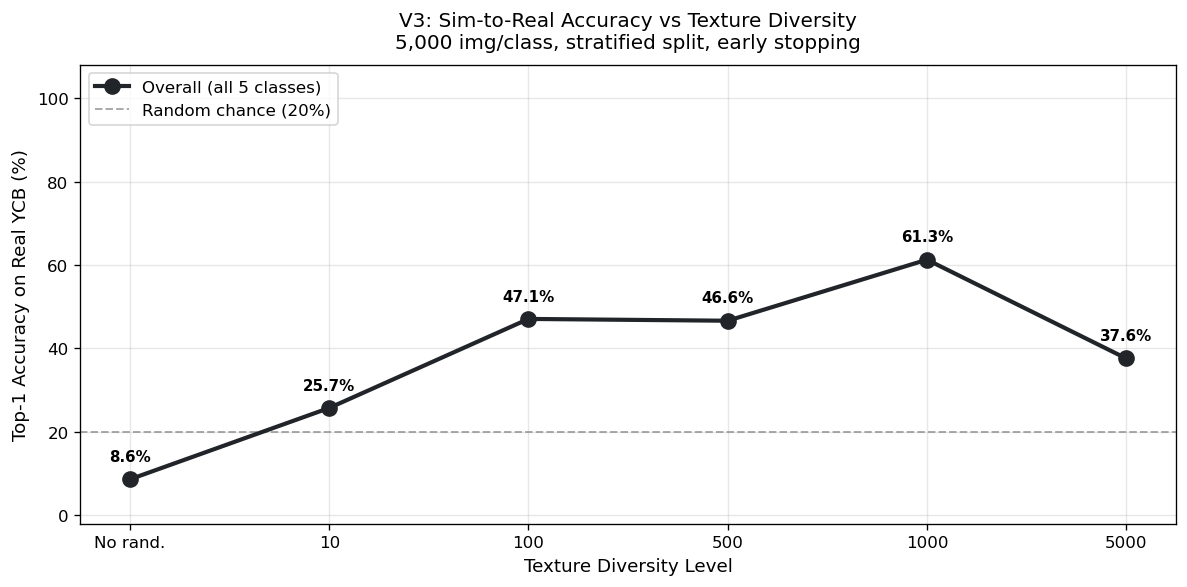

Saved → C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\results_v3\accuracy_curve_overall.png


In [8]:
# ── Accuracy vs diversity — overall (paper figure) ─────────────────────────
x_pos   = list(range(len(ALL_LEVELS)))
x_ticks = ["No rand." if l == 0 else str(l) for l in ALL_LEVELS]

fig, ax = plt.subplots(figsize=(10, 5))
overall_vals = [results_v3[l]["overall"] if l in results_v3 else None
                for l in ALL_LEVELS]

ax.plot(x_pos, overall_vals, "o-", color="#212529",
        linewidth=2.5, markersize=9,
        label="Overall (all 5 classes)", zorder=5)
for x, y in zip(x_pos, overall_vals):
    if y is not None:
        ax.annotate(f"{y:.1f}%", xy=(x, y), xytext=(0, 11),
                    textcoords="offset points", ha="center",
                    fontsize=9, fontweight="bold")

ax.axhline(20, color="#888", linestyle="--", linewidth=1.2, alpha=0.7,
           label="Random chance (20%)")
ax.set_xticks(x_pos); ax.set_xticklabels(x_ticks, fontsize=10)
ax.set_xlabel("Texture Diversity Level", fontsize=11)
ax.set_ylabel("Top-1 Accuracy on Real YCB (%)", fontsize=11)
ax.set_title("V3: Sim-to-Real Accuracy vs Texture Diversity\n"
             "5,000 img/class, stratified split, early stopping",
             fontsize=12, pad=10)
ax.set_ylim(-2, 108)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = RESULTS_DIR_V3 / "accuracy_curve_overall.png"
plt.savefig(str(out), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Results — Confusion Matrices

Per-level confusion matrices on the real test set (rows = true class, columns = predicted, values = % of that true class). These reveal *how* each model fails, not just how often. At no randomization, predictions collapse onto only mug and mustard. At Level 1000, the diagonal is strongest — including the bowl, which earlier versions could not solve.

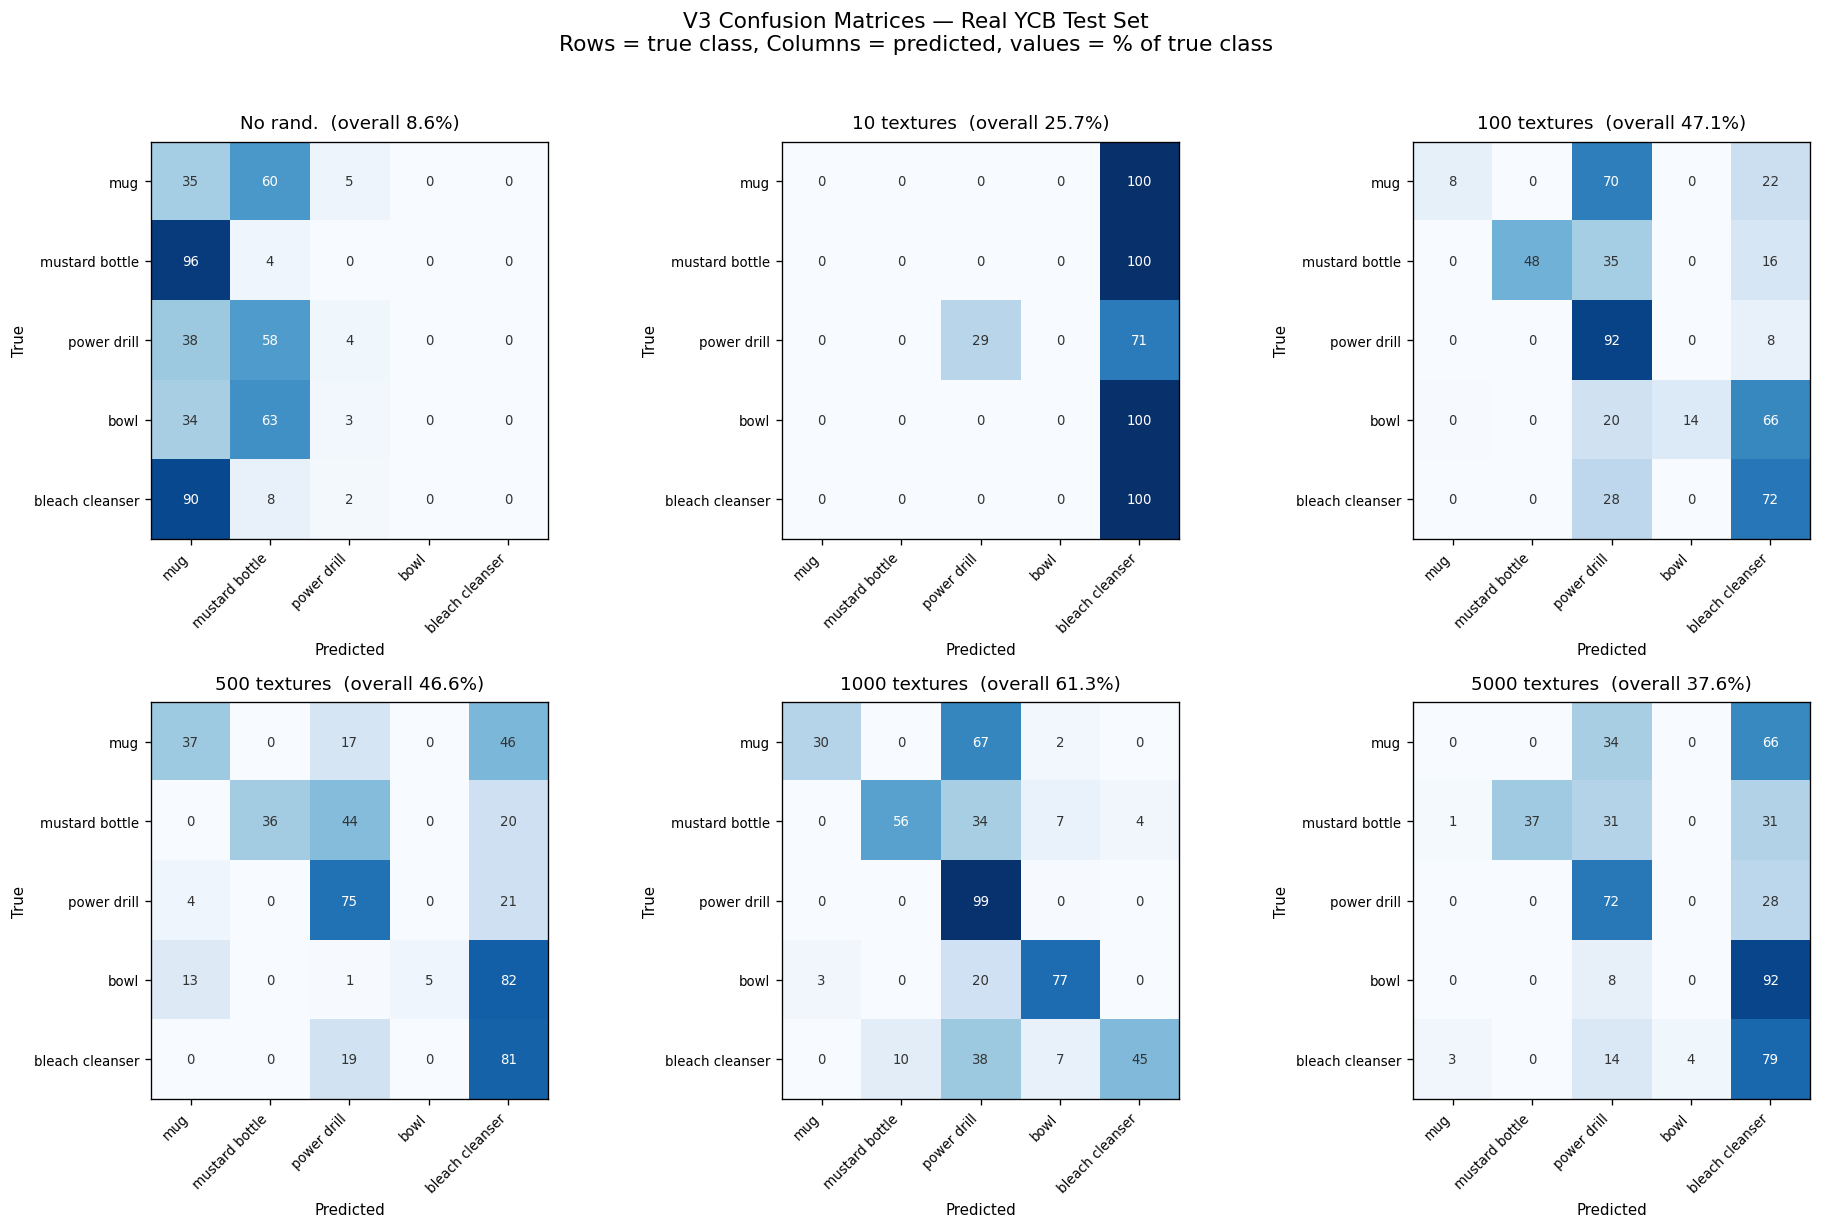

Saved → C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\results_v3\confusion_matrices_v3.png


In [9]:
# ── Confusion matrices — all 6 levels, 2x3 grid ────────────────────────────
short_labels = [o.split("_", 1)[1].replace("_", " ") for o in OBJECTS]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flat

for ax, level in zip(axes, ALL_LEVELS):
    if level not in confusion_v3:
        ax.axis("off"); continue
    cm     = confusion_v3[level]
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    name    = "No rand." if level == 0 else f"{level} textures"
    overall = results_v3[level]["overall"]
    ax.set_title(f"{name}  (overall {overall:.1f}%)", fontsize=11, pad=8)

    ax.set_xticks(range(len(OBJECTS))); ax.set_yticks(range(len(OBJECTS)))
    ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9); ax.set_ylabel("True", fontsize=9)

    for i in range(len(OBJECTS)):
        for j in range(len(OBJECTS)):
            v = cm_pct[i, j]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    fontsize=8, color="white" if v > 50 else "#333")

plt.suptitle("V3 Confusion Matrices — Real YCB Test Set\n"
             "Rows = true class, Columns = predicted, values = % of true class",
             fontsize=13, y=1.02)
plt.tight_layout()
out = RESULTS_DIR_V3 / "confusion_matrices_v3.png"
plt.savefig(str(out), dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Grad-CAM — What the Models Attend To

Grad-CAM (Selvaraju et al. 2017) shows *where* each model looks when making a prediction. It backpropagates the target class score through ResNet-18's last convolutional block (`layer4[-1]`), producing a spatial heatmap: warm regions drove the prediction, cool regions were ignored.

We compare the no-randomization model against the best-performing model for each class. The expected shift — from attending to background/floor to attending to the object itself — is the qualitative evidence that domain randomization changes the network's learned representations.

In [10]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping for ResNet-18.
       Hooks into layer4[-1]. Ref: Selvaraju et al. 2017."""

    def __init__(self, model):
        self.model      = model.eval()
        self._features  = None
        self._gradients = None
        self._hooks     = []
        target = model.layer4[-1]
        self._hooks.append(target.register_forward_hook(self._fwd_hook))
        self._hooks.append(target.register_full_backward_hook(self._bwd_hook))

    def _fwd_hook(self, module, inp, out):
        self._features = out.detach()

    def _bwd_hook(self, module, gin, gout):
        self._gradients = gout[0].detach()

    def generate(self, img_tensor, class_idx=None):
        img_tensor = img_tensor.to(device)
        self.model.zero_grad()
        logits = self.model(img_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        logits[0, class_idx].backward()

        weights = self._gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self._features).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        H, W = img_tensor.shape[2], img_tensor.shape[3]
        return cv2.resize(cam, (W, H)), class_idx

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


def overlay_cam(orig_pil, cam, alpha=0.45):
    orig_np  = np.array(orig_pil.resize((IMG_SIZE, IMG_SIZE)))
    heat_rgb = cv2.cvtColor(
        cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB)
    return Image.fromarray((alpha * heat_rgb + (1 - alpha) * orig_np).astype(np.uint8))


def load_model_weights_v3(texture_level):
    ckpt  = torch.load(MODELS_DIR_V3 / f"model_{get_level_name(texture_level)}.pth",
                       map_location=device)
    model = build_model()
    model.load_state_dict(ckpt["model_state"])
    return model.eval()


print("GradCAM ready | overlay_cam ready | load_model_weights_v3 ready")

GradCAM ready | overlay_cam ready | load_model_weights_v3 ready


Best V3 model per class:
  025_mug                             → Level 500 (37.2%)
  006_mustard_bottle                  → Level 1000 (55.5%)
  035_power_drill                     → Level 1000 (99.2%)
  024_bowl                            → Level 1000 (76.7%)
  021_bleach_cleanser                 → Level 10 (99.7%)


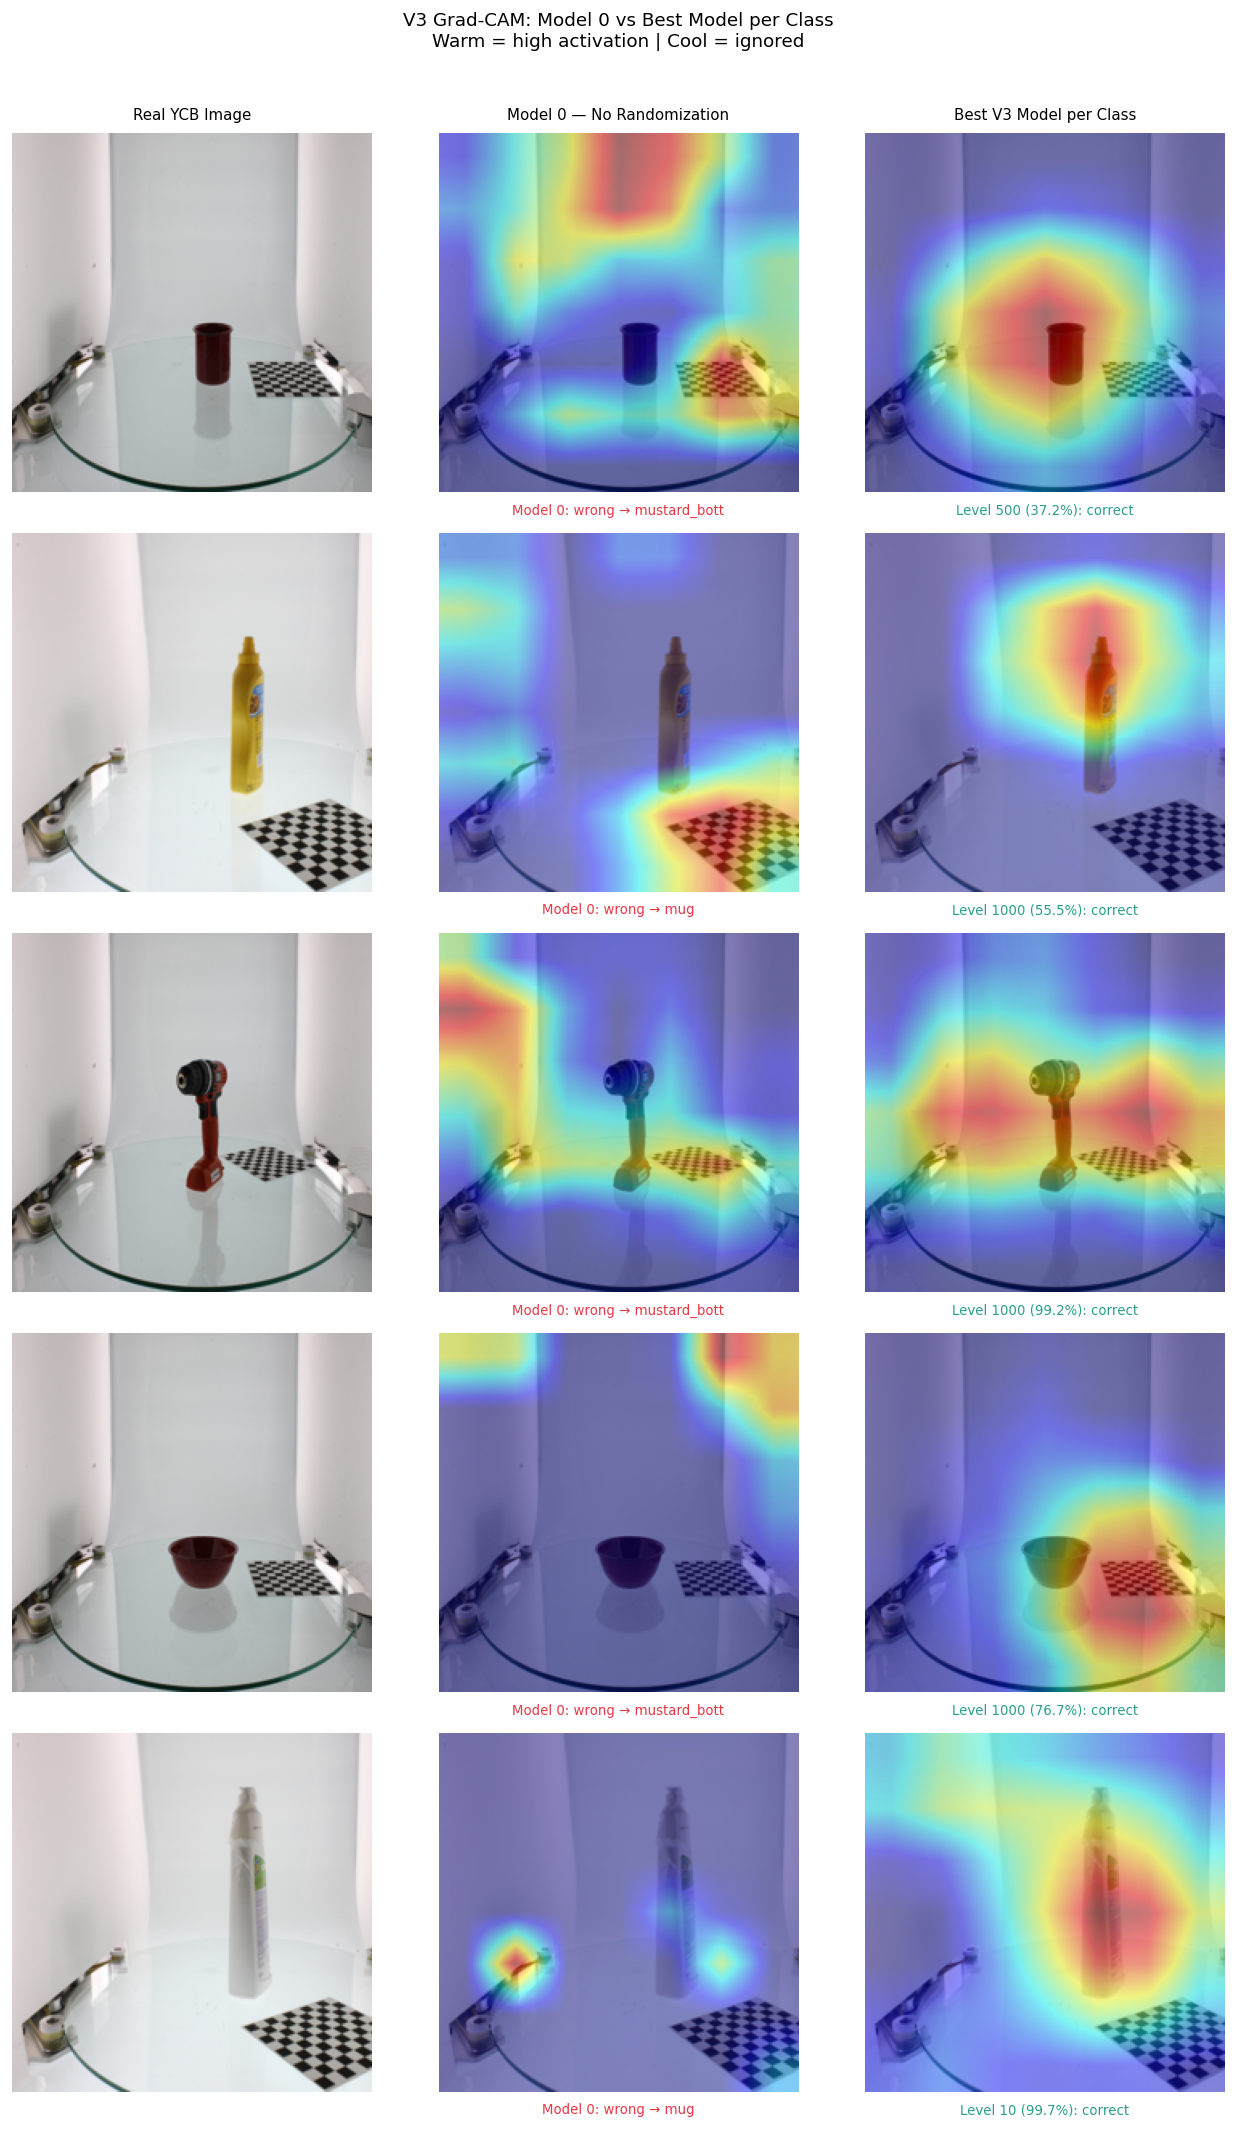

Saved → C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\results_v3\gradcam_v3_per_class_best.png


In [11]:
# ── Grad-CAM: Model 0 vs best model per class ──────────────────────────────
best_level_v3, best_acc_v3 = {}, {}
for i, obj in enumerate(OBJECTS):
    accs = {l: results_v3[l]["per_class"].get(obj, 0)
            for l in ALL_LEVELS if l in results_v3 and l != 0}
    bl = max(accs, key=accs.get)
    best_level_v3[obj], best_acc_v3[obj] = bl, accs[bl]

print("Best V3 model per class:")
for obj in OBJECTS:
    print(f"  {obj:35s} → Level {best_level_v3[obj]} ({best_acc_v3[obj]:.1f}%)")

SAMPLE_IDX = 10
sample_images = []
for class_idx, obj_name in enumerate(OBJECTS):
    imgs = sorted(list((RGB_DIR / obj_name).rglob("*.jpg")) +
                  list((RGB_DIR / obj_name).rglob("*.JPG")))
    if imgs:
        sample_images.append((imgs[min(SAMPLE_IDX, len(imgs)-1)], class_idx, obj_name))

model_0 = load_model_weights_v3(0)
cam_0   = GradCAM(model_0)

fig, axes = plt.subplots(len(sample_images), 3, figsize=(11, 3.5*len(sample_images)))
axes[0,0].set_title("Real YCB Image", fontsize=9, pad=8)
axes[0,1].set_title("Model 0 — No Randomization", fontsize=9, pad=8)
axes[0,2].set_title("Best V3 Model per Class", fontsize=9, pad=8)

for row, (img_path, true_class, obj_name) in enumerate(sample_images):
    orig  = Image.open(img_path).convert("RGB")
    img_t = test_transform(orig).unsqueeze(0)
    short = obj_name.split("_", 1)[1].replace("_", " ")
    blevel, bacc = best_level_v3[obj_name], best_acc_v3[obj_name]

    axes[row,0].imshow(orig.resize((IMG_SIZE, IMG_SIZE)))
    axes[row,0].set_ylabel(f"Class {true_class}\n{short}", fontsize=8,
                           rotation=90, labelpad=5, va="center")
    axes[row,0].axis("off")

    with torch.no_grad():
        pred0 = int(model_0(img_t.clone().to(device)).argmax(1).item())
    c0 = pred0 == true_class
    h0, _ = cam_0.generate(img_t.clone(), class_idx=true_class)
    axes[row,1].imshow(overlay_cam(orig, h0)); axes[row,1].axis("off")
    axes[row,1].text(0.5, -0.03,
                     f"Model 0: {'correct' if c0 else 'wrong → '+OBJECTS[pred0].split('_',1)[1][:12]}",
                     transform=axes[row,1].transAxes, ha="center", va="top",
                     fontsize=8, color="#2A9D8F" if c0 else "#E63946")

    mbest = load_model_weights_v3(blevel)
    with torch.no_grad():
        predb = int(mbest(img_t.clone().to(device)).argmax(1).item())
    cb = predb == true_class
    cam_b = GradCAM(mbest)
    hb, _ = cam_b.generate(img_t.clone(), class_idx=true_class)
    axes[row,2].imshow(overlay_cam(orig, hb)); axes[row,2].axis("off")
    axes[row,2].text(0.5, -0.03,
                     f"Level {blevel} ({bacc:.1f}%): {'correct' if cb else 'wrong → '+OBJECTS[predb].split('_',1)[1][:12]}",
                     transform=axes[row,2].transAxes, ha="center", va="top",
                     fontsize=8, color="#2A9D8F" if cb else "#E63946")
    cam_b.remove_hooks(); del mbest, cam_b

plt.suptitle("V3 Grad-CAM: Model 0 vs Best Model per Class\n"
             "Warm = high activation | Cool = ignored", fontsize=11, y=1.01)
plt.tight_layout()
out = RESULTS_DIR_V3 / "gradcam_v3_per_class_best.png"
plt.savefig(str(out), dpi=200, bbox_inches="tight")
plt.show()
cam_0.remove_hooks(); del model_0
print(f"Saved → {out}")

## Ablation — The Role of ImageNet Pretraining

To isolate how much of the transfer comes from ImageNet pretraining versus the domain randomization itself, we retrain ResNet-18 **from random initialization** (no pretraining) on the same synthetic data, for two levels: no randomization and the best pretrained level (1000).

This directly tests whether pretrained features are necessary. If from-scratch performs far worse, it shows that domain randomization and pretraining work together — neither alone is sufficient at this data scale.

In [12]:
def build_model_scratch(num_classes=5):
    """ResNet-18 with RANDOM weights — no ImageNet pretraining."""
    model    = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def train_scratch(texture_level, verbose=True):
    from collections import defaultdict
    level_name = get_level_name(texture_level)
    model_path = MODELS_DIR_V3 / f"model_{level_name}_scratch.pth"

    if model_path.exists():
        ckpt = torch.load(model_path, map_location="cpu")
        if verbose:
            print(f"  [{level_name} scratch] checkpoint found — skipping")
        return ckpt.get("history")

    if verbose:
        print(f"\n  Training FROM SCRATCH : {level_name}")

    full_ds = SyntheticDataset_V3(texture_level, transform=train_transform)
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(full_ds.samples):
        class_indices[label].append(idx)
    rng = random.Random(42)
    train_idx, val_idx = [], []
    for label, idxs in class_indices.items():
        idxs = idxs.copy(); rng.shuffle(idxs)
        nv = int(len(idxs) * VAL_FRACTION)
        val_idx.extend(idxs[:nv]); train_idx.extend(idxs[nv:])

    train_loader = DataLoader(Subset(full_ds, train_idx), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(Subset(full_ds, val_idx), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    model     = build_model_scratch()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                     factor=0.5, patience=3)
    history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
    best_vl, best_state, no_imp, stopped = float("inf"), None, 0, MAX_EPOCHS

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train(); rl, c, t = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs); loss = criterion(logits, labels)
            loss.backward(); optimizer.step()
            rl += loss.item()*imgs.size(0); _, pr = logits.max(1)
            t += labels.size(0); c += pr.eq(labels).sum().item()
        tr_loss, tr_acc = rl/t, 100.0*c/t

        model.eval(); vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs); loss = criterion(logits, labels)
                vl += loss.item()*imgs.size(0); _, pr = logits.max(1)
                vt += labels.size(0); vc += pr.eq(labels).sum().item()
        val_loss, val_acc = vl/vt, 100.0*vc/vt

        for k, v in [("loss",tr_loss),("acc",tr_acc),("val_loss",val_loss),("val_acc",val_acc)]:
            history[k].append(round(v, 5 if "loss" in k else 2))
        scheduler.step(val_loss)

        if val_loss < best_vl - 1e-4:
            best_vl = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if verbose and (epoch <= 3 or epoch % 10 == 0 or no_imp >= ES_PATIENCE):
            print(f"  Epoch {epoch:03d}  tr_acc={tr_acc:5.1f}%  val_acc={val_acc:5.1f}%  (no improve: {no_imp})")
        if no_imp >= ES_PATIENCE:
            stopped = epoch
            if verbose: print(f"  Early stop at epoch {epoch}")
            break

    if best_state: model.load_state_dict(best_state)
    history["stopped_epoch"] = stopped
    torch.save({"texture_level": texture_level, "level_name": level_name,
                "model_state": model.state_dict(), "history": history,
                "objects": OBJECTS, "num_classes": len(OBJECTS),
                "pretrained": False}, model_path)
    if verbose: print(f"  Saved → {model_path.name}")
    return history


def evaluate_scratch(texture_level):
    model_path = MODELS_DIR_V3 / f"model_{get_level_name(texture_level)}_scratch.pth"
    if not model_path.exists(): return None
    ckpt  = torch.load(model_path, map_location=device)
    model = build_model_scratch(); model.load_state_dict(ckpt["model_state"]); model.eval()
    loader = DataLoader(RealYCBDataset(transform=test_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    preds, labs = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            _, pr = model(imgs.to(device)).max(1)
            preds.extend(pr.cpu().tolist()); labs.extend(labels.tolist())
    return 100.0 * (np.array(preds) == np.array(labs)).mean()


# ── Run ablation for no-rand and best pretrained level ─────────────────────
best_pretrained_level = max((l for l in ALL_LEVELS if l in results_v3 and l != 0),
                            key=lambda l: results_v3[l]["overall"])
scratch_levels = sorted(set([0, best_pretrained_level]))

print("=" * 58)
print(f"  FROM-SCRATCH ABLATION — levels {scratch_levels}")
print("=" * 58)

scratch_results = {}
for level in scratch_levels:
    train_scratch(level, verbose=True)
    scratch_results[level] = evaluate_scratch(level)
    print(f"  {get_level_name(level)} scratch test accuracy: {scratch_results[level]:.1f}%\n")

print(f"  {'Level':<20}  {'Pretrained':>11}  {'From scratch':>13}  {'Difference':>11}")
print(f"  {'-'*20}  {'-'*11}  {'-'*13}  {'-'*11}")
for level in scratch_levels:
    name = get_level_name(level)
    pre  = results_v3.get(level, {}).get("overall", float('nan'))
    scr  = scratch_results.get(level, float('nan'))
    print(f"  {name:<20}  {pre:>10.1f}%  {scr:>12.1f}%  {pre-scr:>10.1f}%")

  FROM-SCRATCH ABLATION — levels [0, 1000]
  [no_randomization scratch] checkpoint found — skipping
  no_randomization scratch test accuracy: 20.0%

  [textures_01000 scratch] checkpoint found — skipping
  textures_01000 scratch test accuracy: 25.0%

  Level                  Pretrained   From scratch   Difference
  --------------------  -----------  -------------  -----------
  no_randomization             8.6%          20.0%       -11.4%
  textures_01000              61.3%          25.0%        36.3%


## Ablation Robustness Check — From-Scratch with Tuned Learning Rate

The original from-scratch ablation used `lr=1e-4` (the same as the fine-tuned models). Training from random initialization typically benefits from a higher learning rate, so this check re-runs the from-scratch models with `lr=1e-3` (10×) to confirm the pretraining gap is not an artefact of under-tuned from-scratch training.

Results save to **new checkpoint files** (`model_*_scratch_lr1e3.pth`) — the original ablation results used in the paper are never overwritten. Only the two ablation levels are run: no randomization and the best pretrained level.

In [13]:
# ── Ablation robustness: from-scratch with lr=1e-3 (does NOT touch originals) ──
from collections import defaultdict
from torch.utils.data import Subset

SCRATCH_LR = 1e-3   # 10× the fine-tuning LR — proper for training from random init

def build_model_scratch_local(num_classes=5):
    """ResNet-18, random init (no pretraining). Defined locally so this cell
       is self-contained and does not depend on earlier ablation cells."""
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)


def train_scratch_tuned(texture_level, lr=SCRATCH_LR, verbose=True):
    """Train from scratch at the given LR. Saves to a *_scratch_lr1e3.pth file."""
    level_name = get_level_name(texture_level)
    model_path = MODELS_DIR_V3 / f"model_{level_name}_scratch_lr1e3.pth"

    if model_path.exists():
        ckpt = torch.load(model_path, map_location="cpu")
        if verbose:
            print(f"  [{level_name} scratch lr1e3] checkpoint found — skipping")
        return ckpt.get("history")

    if verbose:
        print(f"\n  Training FROM SCRATCH (lr={lr}) : {level_name}")

    full_ds = SyntheticDataset_V3(texture_level, transform=train_transform)

    # Stratified split — identical scheme to the pretrained V3 models
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(full_ds.samples):
        class_indices[label].append(idx)
    rng = random.Random(42)
    train_idx, val_idx = [], []
    for label, idxs in class_indices.items():
        idxs = idxs.copy(); rng.shuffle(idxs)
        nv = int(len(idxs) * VAL_FRACTION)
        val_idx.extend(idxs[:nv]); train_idx.extend(idxs[nv:])

    train_loader = DataLoader(Subset(full_ds, train_idx), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(Subset(full_ds, val_idx), batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=0, pin_memory=True)

    model     = build_model_scratch_local()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                     factor=0.5, patience=3)
    history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
    best_vl, best_state, no_imp, stopped = float("inf"), None, 0, MAX_EPOCHS

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train(); rl, c, t = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs); loss = criterion(logits, labels)
            loss.backward(); optimizer.step()
            rl += loss.item()*imgs.size(0); _, pr = logits.max(1)
            t += labels.size(0); c += pr.eq(labels).sum().item()
        tr_loss, tr_acc = rl/t, 100.0*c/t

        model.eval(); vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs); loss = criterion(logits, labels)
                vl += loss.item()*imgs.size(0); _, pr = logits.max(1)
                vt += labels.size(0); vc += pr.eq(labels).sum().item()
        val_loss, val_acc = vl/vt, 100.0*vc/vt

        for k, v in [("loss",tr_loss),("acc",tr_acc),("val_loss",val_loss),("val_acc",val_acc)]:
            history[k].append(round(v, 5 if "loss" in k else 2))
        scheduler.step(val_loss)

        if val_loss < best_vl - 1e-4:
            best_vl = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if verbose and (epoch <= 3 or epoch % 10 == 0 or no_imp >= ES_PATIENCE):
            print(f"    Epoch {epoch:03d}  tr_acc={tr_acc:5.1f}%  "
                  f"val_acc={val_acc:5.1f}%  (no improve: {no_imp})")
        if no_imp >= ES_PATIENCE:
            stopped = epoch
            if verbose: print(f"    Early stop at epoch {epoch}")
            break

    if best_state: model.load_state_dict(best_state)
    history["stopped_epoch"] = stopped
    torch.save({"texture_level": texture_level, "level_name": level_name,
                "model_state": model.state_dict(), "history": history,
                "objects": OBJECTS, "num_classes": len(OBJECTS),
                "pretrained": False, "lr": lr}, model_path)
    if verbose: print(f"    Saved → {model_path.name}")
    return history


def evaluate_scratch_tuned(texture_level):
    """Evaluate a tuned-scratch model on real YCB images. Returns overall accuracy."""
    model_path = MODELS_DIR_V3 / f"model_{get_level_name(texture_level)}_scratch_lr1e3.pth"
    if not model_path.exists():
        return None
    ckpt  = torch.load(model_path, map_location=device)
    model = build_model_scratch_local()
    model.load_state_dict(ckpt["model_state"]); model.eval()
    loader = DataLoader(RealYCBDataset(transform=test_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    preds, labs = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            _, pr = model(imgs.to(device)).max(1)
            preds.extend(pr.cpu().tolist()); labs.extend(labels.tolist())
    return 100.0 * (np.array(preds) == np.array(labs)).mean()


# ── Pick the two ablation levels ───────────────────────────────────────────
# Best pretrained level from results_v3 if available, else default to 1000.
try:
    best_pre = max((l for l in ALL_LEVELS if l in results_v3 and l != 0),
                   key=lambda l: results_v3[l]["overall"])
except (NameError, ValueError):
    best_pre = 1000
    print("Note: results_v3 not in memory — defaulting best level to 1000.")

ablation_levels = sorted(set([0, best_pre]))

print("=" * 60)
print(f"  FROM-SCRATCH ROBUSTNESS — lr={SCRATCH_LR}, levels {ablation_levels}")
print("=" * 60)

scratch_lr3_results = {}
for level in ablation_levels:
    train_scratch_tuned(level, lr=SCRATCH_LR, verbose=True)
    scratch_lr3_results[level] = evaluate_scratch_tuned(level)
    print(f"  {get_level_name(level)} scratch(lr1e3) test acc: "
          f"{scratch_lr3_results[level]:.1f}%\n")

# ── Comparison table: pretrained vs scratch(1e-4) vs scratch(1e-3) ─────────
print(f"  {'Level':<20}  {'Pretrained':>11}  {'Scratch 1e-4':>13}  {'Scratch 1e-3':>13}")
print(f"  {'-'*20}  {'-'*11}  {'-'*13}  {'-'*13}")
for level in ablation_levels:
    name = get_level_name(level)
    # pretrained
    try:
        pre = results_v3[level]["overall"]
    except (NameError, KeyError):
        pre = float('nan')
    # original scratch (lr 1e-4) — load saved checkpoint's eval if present
    orig_path = MODELS_DIR_V3 / f"model_{name}_scratch.pth"
    if orig_path.exists():
        ck = torch.load(orig_path, map_location=device)
        m  = build_model_scratch_local(); m.load_state_dict(ck["model_state"]); m.eval()
        ldr = DataLoader(RealYCBDataset(transform=test_transform),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        pp, ll = [], []
        with torch.no_grad():
            for imgs, labels in ldr:
                _, pr = m(imgs.to(device)).max(1)
                pp.extend(pr.cpu().tolist()); ll.extend(labels.tolist())
        scr_1e4 = 100.0 * (np.array(pp) == np.array(ll)).mean()
        del m
    else:
        scr_1e4 = float('nan')
    scr_1e3 = scratch_lr3_results.get(level, float('nan'))
    print(f"  {name:<20}  {pre:>10.1f}%  {scr_1e4:>12.1f}%  {scr_1e3:>12.1f}%")

# ── Save to disk ───────────────────────────────────────────────────────────
with open(RESULTS_DIR_V3 / "scratch_lr_comparison.txt", "w") as f:
    f.write("FROM-SCRATCH LEARNING-RATE ROBUSTNESS CHECK\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"{'Level':<20}  {'Scratch 1e-3 test acc':>22}\n")
    for level in ablation_levels:
        name = get_level_name(level)
        f.write(f"{name:<20}  {scratch_lr3_results.get(level, float('nan')):>21.1f}%\n")
print("\nSaved → scratch_lr_comparison.txt")

  FROM-SCRATCH ROBUSTNESS — lr=0.001, levels [0, 1000]
  [no_randomization scratch lr1e3] checkpoint found — skipping
  no_randomization scratch(lr1e3) test acc: 20.0%

  [textures_01000 scratch lr1e3] checkpoint found — skipping
  textures_01000 scratch(lr1e3) test acc: 28.4%

  Level                  Pretrained   Scratch 1e-4   Scratch 1e-3
  --------------------  -----------  -------------  -------------
  no_randomization             8.6%          20.0%          20.0%
  textures_01000              61.3%          25.0%          28.4%

Saved → scratch_lr_comparison.txt
